# Part 1: Experiment Tracking with MLflow
## Task 1.1: MLflow Setup & Experiment Logging

#### Setup, MLflow Initialization, and Data Loading

The code below initializes the environment for model evaluation and experiment tracking by importing essential libraries and connecting to a local MLflow server. It subsequently establishes the "taxi-tip-prediction" experiment to log future model iterations. Finally, local data directories are configured to automatically retrieve the necessary taxi zone lookup table and load the pre-processed parquet dataset into a pandas DataFrame for analysis.

In [11]:
#pip install numpy pandas pathlib pyarrow fastparquet requests scikit-learn matplotlib
import numpy as np
import pandas as pd
from pathlib import Path
import requests
import sklearn
import matplotlib
import mlflow
import mlflow.sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, f1_score

#Points to local tracking server
mlflow.set_tracking_uri("http://localhost:5000")

#Creates the experiment
mlflow.set_experiment("taxi-tip-prediction")

#Creates data directory and download the taxi zone lookup dataset if it is not already available locally
raw_path = Path("data/raw")
raw_path.mkdir(parents=True, exist_ok=True)

def download_file(url, save_path):
    if not save_path.exists():  
        print(f"Downloading {save_path.name}...")
        response = requests.get(url)
        response.raise_for_status()
        with open(save_path, "wb") as f:
            f.write(response.content)
        print("Download complete.")
    else:
        print(f"{save_path.name} already exists.")  

#Download zone lookup file
zone_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
zone_path = raw_path / "taxi_zone_lookup.csv"
download_file(zone_url, zone_path)  
zones = pd.read_csv(zone_path)  

#Load cleaned data file
CLEAN_PATH = Path("data/processed/cleaned_taxi_2024_01.parquet")
df = pd.read_parquet(CLEAN_PATH, engine="pyarrow")

2026/04/13 23:34:17 INFO mlflow.tracking.fluent: Experiment with name 'taxi-tip-prediction' does not exist. Creating a new experiment.


taxi_zone_lookup.csv already exists.


#### Feature Engineering and Data Splitting

Temporal, spatial, and financial features are extracted to reconstruct the predictive variables established in Assignment 2. The refined dataset is subsequently cleansed of invalid entries and stratified into distinct training, validation, and testing subsets to ensure reproducible model evaluation.

In [12]:
#Filter dataset to include only credit card payments
df = df[df["payment_type"] == 1].copy()

#Ensure datetime
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

#Temporal features
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek
df["is_weekend"] = df["pickup_day_of_week"].isin([5,6])

#Trip features
df["trip_duration_minutes"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60.0
duration_hours = df["trip_duration_minutes"] / 60.0
df["trip_speed_mph"] = np.where(duration_hours > 0, df["trip_distance"] / duration_hours, np.nan)
df["log_trip_distance"] = np.log1p(df["trip_distance"])

#Fare features
df["fare_per_mile"] = np.where(df["trip_distance"] > 0, df["fare_amount"] / df["trip_distance"], np.nan)
df["fare_per_minute"] = np.where(df["trip_duration_minutes"] > 0, df["fare_amount"] / df["trip_duration_minutes"], np.nan)

#Targets
df["tip_amount_target"] = df["tip_amount"]  
tip_pct = np.where(df["fare_amount"] > 0, df["tip_amount"] / df["fare_amount"], 0)
df["high_tip"] = (tip_pct > 0.20).astype(int) 

#Merge Zones
zones_small = zones[["LocationID", "Borough"]].copy()
df = df.merge(zones_small, left_on="PULocationID", right_on="LocationID", how="left", suffixes=("", "_zonePU")).rename(columns={"Borough": "PU_Borough"})
for col in ["LocationID", "LocationID_zonePU"]:
    if col in df.columns:
        df = df.drop(columns=[col])

df = df.merge(zones_small, left_on="DOLocationID", right_on="LocationID", how="left", suffixes=("", "_zoneDO")).rename(columns={"Borough": "DO_Borough"})
for col in ["LocationID", "LocationID_zoneDO"]:
    if col in df.columns:
        df = df.drop(columns=[col])

to_drop = [c for c in df.columns if c.startswith("LocationID_")]
if to_drop:
    df = df.drop(columns=to_drop)

#Define features and clean dataset
model_cols = [
    "pickup_hour", "pickup_day_of_week", "is_weekend", "trip_duration_minutes", "trip_speed_mph", "log_trip_distance",
    "fare_per_mile", "fare_per_minute", "PU_Borough", "DO_Borough", "passenger_count", "trip_distance", "fare_amount", 
    "total_amount", "tip_amount_target", "high_tip"
]
df_model = df[model_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

#Train/Test Split
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["tip_amount_target", "high_tip"])
y_reg = df_model["tip_amount_target"].values
y_clf = df_model["high_tip"].values  

X_trainval, X_test, y_reg_trainval, y_reg_test, y_clf_trainval, y_clf_test = train_test_split(X, y_reg, y_clf, test_size=0.15, random_state=42, stratify=y_clf)
val_size = 0.15 / 0.85
X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = train_test_split(X_trainval, y_reg_trainval, y_clf_trainval, test_size=val_size, random_state=42, stratify=y_clf_trainval)

#### Preprocessing and Pipeline Definitions

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

#Feature lists
numeric_features = [
    "pickup_hour", "pickup_day_of_week", "trip_duration_minutes", "trip_speed_mph", "log_trip_distance",
    "fare_per_mile", "fare_per_minute", "passenger_count", "trip_distance", "is_weekend"  
]
categorical_features = ["PU_Borough", "DO_Borough"]

#Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=False), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_features),
    ],
    remainder="drop",
    sparse_threshold=1.0
)

#Baseline Pipelines
linreg_pipe = Pipeline([("prep", preprocessor), ("model", LinearRegression())])
rfreg_pipe = Pipeline([
    ("prep", preprocessor), 
    ("model", RandomForestRegressor(
        n_estimators=30, 
        max_depth=14, 
        min_samples_leaf=5, 
        max_features="sqrt",
        n_jobs=-1, 
        random_state=42
    ))
])
logreg_pipe = Pipeline([("prep", preprocessor), ("model", LogisticRegression(max_iter=1000, solver="lbfgs"))])

#Tuned Pipeline
best_rfclf = Pipeline([
    ("prep", preprocessor), 
    ("model", RandomForestClassifier(
        n_estimators=70, 
        max_depth=16, 
        min_samples_leaf=10, 
        max_samples=0.3, 
        max_features=0.5, 
        random_state=42, 
        n_jobs=-1
    ))
])

#### Model Training and MLflow Logging

In [14]:
dataset_name = "cleaned_taxi_2024_01.parquet"

# 1. Linear Regression
with mlflow.start_run(run_name="Linear_Regression"):
    mlflow.set_tag("model_type", "Linear Regression")
    mlflow.set_tag("dataset_version", dataset_name)
    
    print("Retraining Linear Regression...")
    linreg_pipe.fit(X_train, y_reg_train)
    
    y_pred_reg = linreg_pipe.predict(X_test)
    mlflow.log_metric("MAE", mean_absolute_error(y_reg_test, y_pred_reg))
    mlflow.log_metric("RMSE", np.sqrt(mean_squared_error(y_reg_test, y_pred_reg)))
    mlflow.log_metric("R2", r2_score(y_reg_test, y_pred_reg))
    mlflow.sklearn.log_model(linreg_pipe, "model")
    print("Linear Regression logged successfully!")

# 2. Random Forest Regressor
with mlflow.start_run(run_name="Random_Forest_Regressor"):
    mlflow.set_tag("model_type", "Random Forest Regressor")
    mlflow.set_tag("dataset_version", dataset_name)
    
    rf_params = rfreg_pipe.named_steps["model"].get_params()
    mlflow.log_param("n_estimators", rf_params["n_estimators"])
    mlflow.log_param("max_depth", rf_params["max_depth"])
    
    print("Retraining Random Forest Regressor...")
    rfreg_pipe.fit(X_train, y_reg_train)
    
    y_pred_rf = rfreg_pipe.predict(X_test)
    mlflow.log_metric("MAE", mean_absolute_error(y_reg_test, y_pred_rf))
    mlflow.log_metric("RMSE", np.sqrt(mean_squared_error(y_reg_test, y_pred_rf)))
    mlflow.log_metric("R2", r2_score(y_reg_test, y_pred_rf))
    mlflow.sklearn.log_model(rfreg_pipe, "model")
    print("Random Forest Regressor logged successfully!")

# 3. Logistic Regression
with mlflow.start_run(run_name="Logistic_Regression"):
    mlflow.set_tag("model_type", "Logistic Regression")
    mlflow.set_tag("dataset_version", dataset_name)
    
    print("Retraining Logistic Regression...")
    logreg_pipe.fit(X_train, y_clf_train)
    
    y_pred_clf = logreg_pipe.predict(X_test)
    mlflow.log_metric("Accuracy", accuracy_score(y_clf_test, y_pred_clf))
    mlflow.log_metric("F1", f1_score(y_clf_test, y_pred_clf))
    mlflow.sklearn.log_model(logreg_pipe, "model")
    print("Logistic Regression logged successfully!")

# 4. Tuned Random Forest
with mlflow.start_run(run_name="Random_Forest_Tuned"):
    mlflow.set_tag("model_type", "Random Forest Tuned")
    mlflow.set_tag("dataset_version", dataset_name)
    
    print("Retraining Tuned Random Forest...")
    best_rfclf.fit(X_train, y_clf_train)
    
    y_pred_tuned = best_rfclf.predict(X_test)
    mlflow.log_params(best_rfclf.named_steps["model"].get_params())
    mlflow.log_metric("Accuracy", accuracy_score(y_clf_test, y_pred_tuned))
    mlflow.log_metric("F1", f1_score(y_clf_test, y_pred_tuned))
    mlflow.sklearn.log_model(best_rfclf, "model")
    print("Tuned Random Forest logged successfully!")

Retraining Linear Regression...


2026/04/13 23:34:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 23:34:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression logged successfully!
🏃 View run Linear_Regression at: http://localhost:5000/#/experiments/563438685059177018/runs/d448faa8e4cb4b0c81ff7bb60f705f97
🧪 View experiment at: http://localhost:5000/#/experiments/563438685059177018
Retraining Random Forest Regressor...


2026/04/13 23:35:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 23:35:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Regressor logged successfully!
🏃 View run Random_Forest_Regressor at: http://localhost:5000/#/experiments/563438685059177018/runs/b6fb168a12fe4dd1bdd527bb5e8392e1
🧪 View experiment at: http://localhost:5000/#/experiments/563438685059177018
Retraining Logistic Regression...


2026/04/13 23:35:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 23:35:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression logged successfully!
🏃 View run Logistic_Regression at: http://localhost:5000/#/experiments/563438685059177018/runs/4c564670a2be436fabb36de8a0888de6
🧪 View experiment at: http://localhost:5000/#/experiments/563438685059177018
Retraining Tuned Random Forest...


2026/04/13 23:39:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 23:39:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tuned Random Forest logged successfully!
🏃 View run Random_Forest_Tuned at: http://localhost:5000/#/experiments/563438685059177018/runs/459831c266384627ad8ffb63857e989c
🧪 View experiment at: http://localhost:5000/#/experiments/563438685059177018


MLflow UI showing all logged runs with metrics, parameters and tags.

![MLflow UI 1.1.png](<attachment:MLflow UI 1.1.png>)
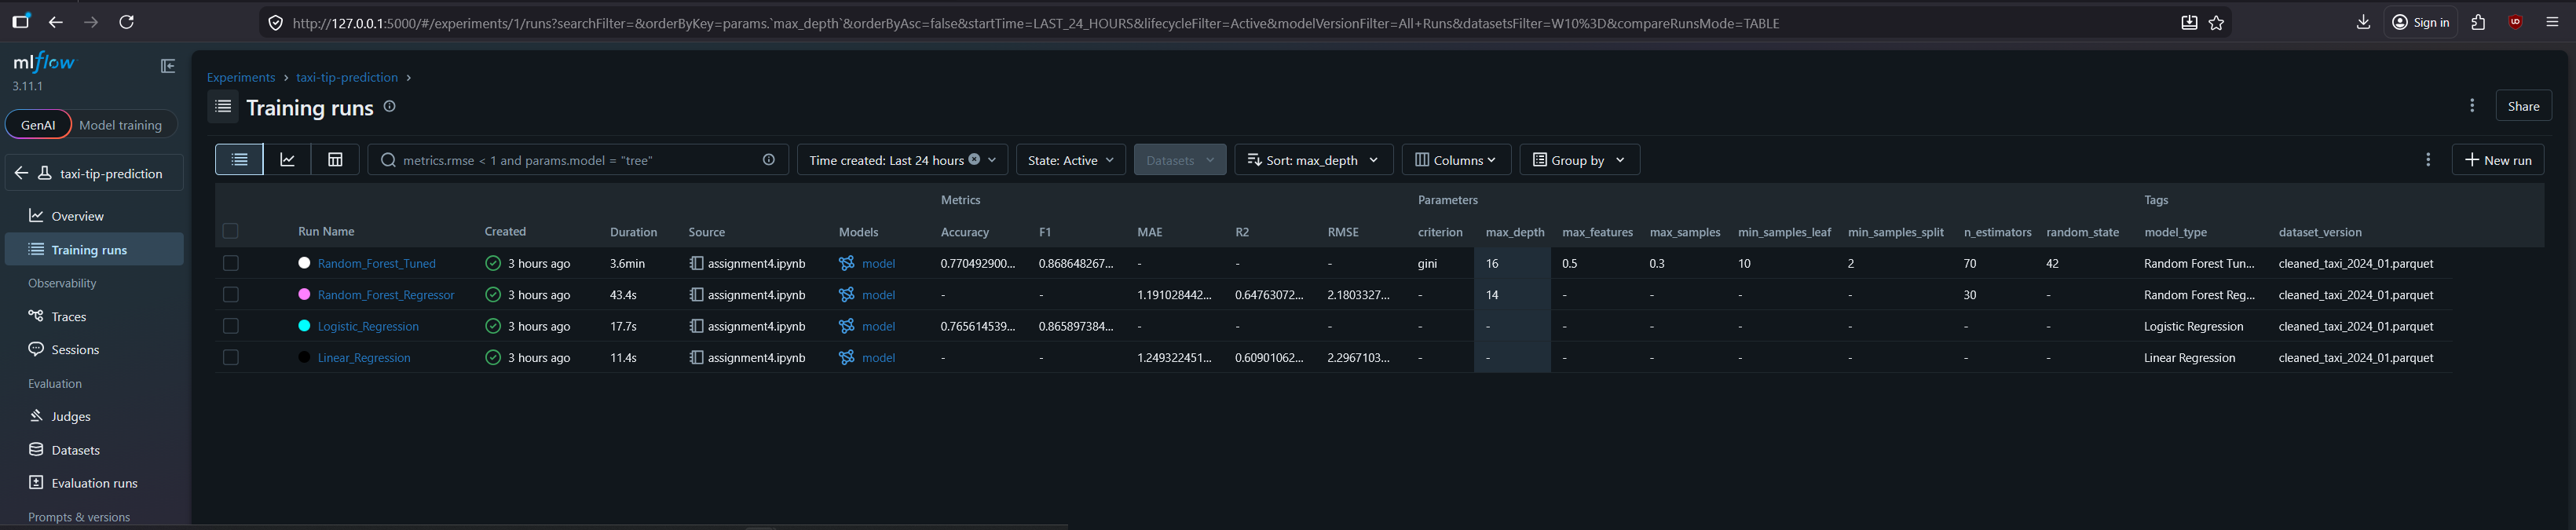

MLflow UI showing tags: model type and dataset version applied to logged runs.


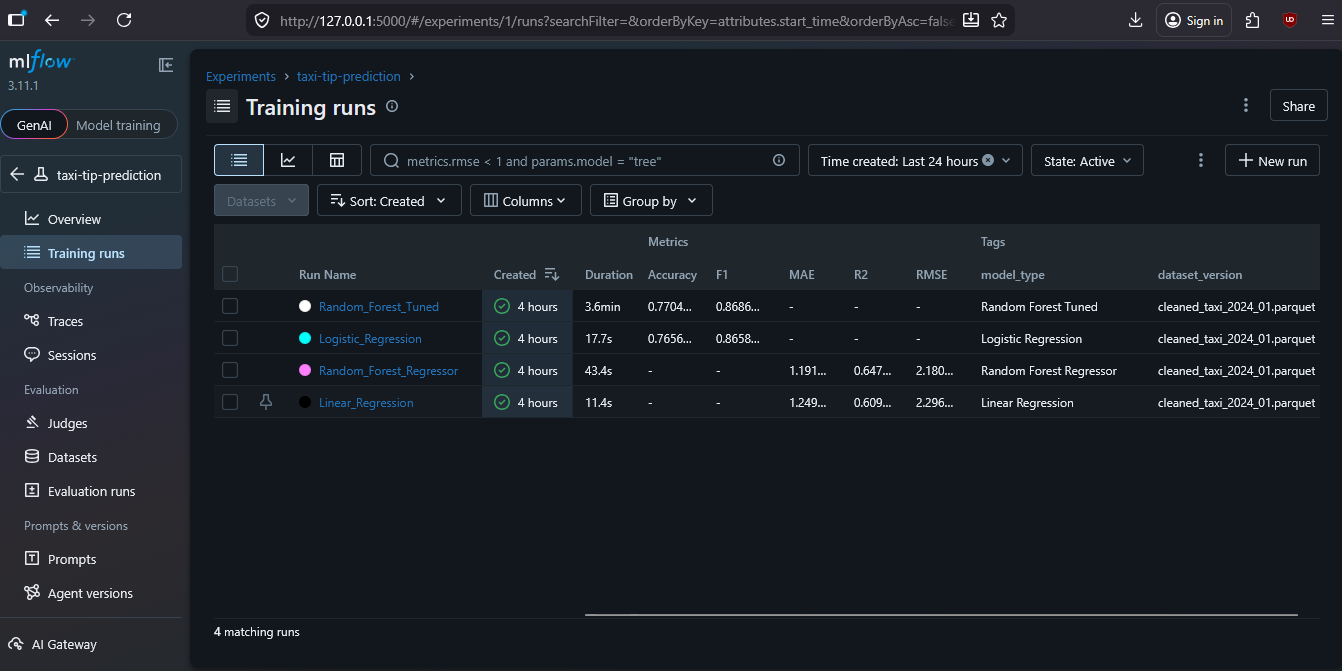

## Task 1.2: Model Comparison & Registry

MLflow UI showing comparison view comparing model performance.

![MLflow Comparison View 1.2.png](<attachment:MLflow Comparison View 1.2.png>)
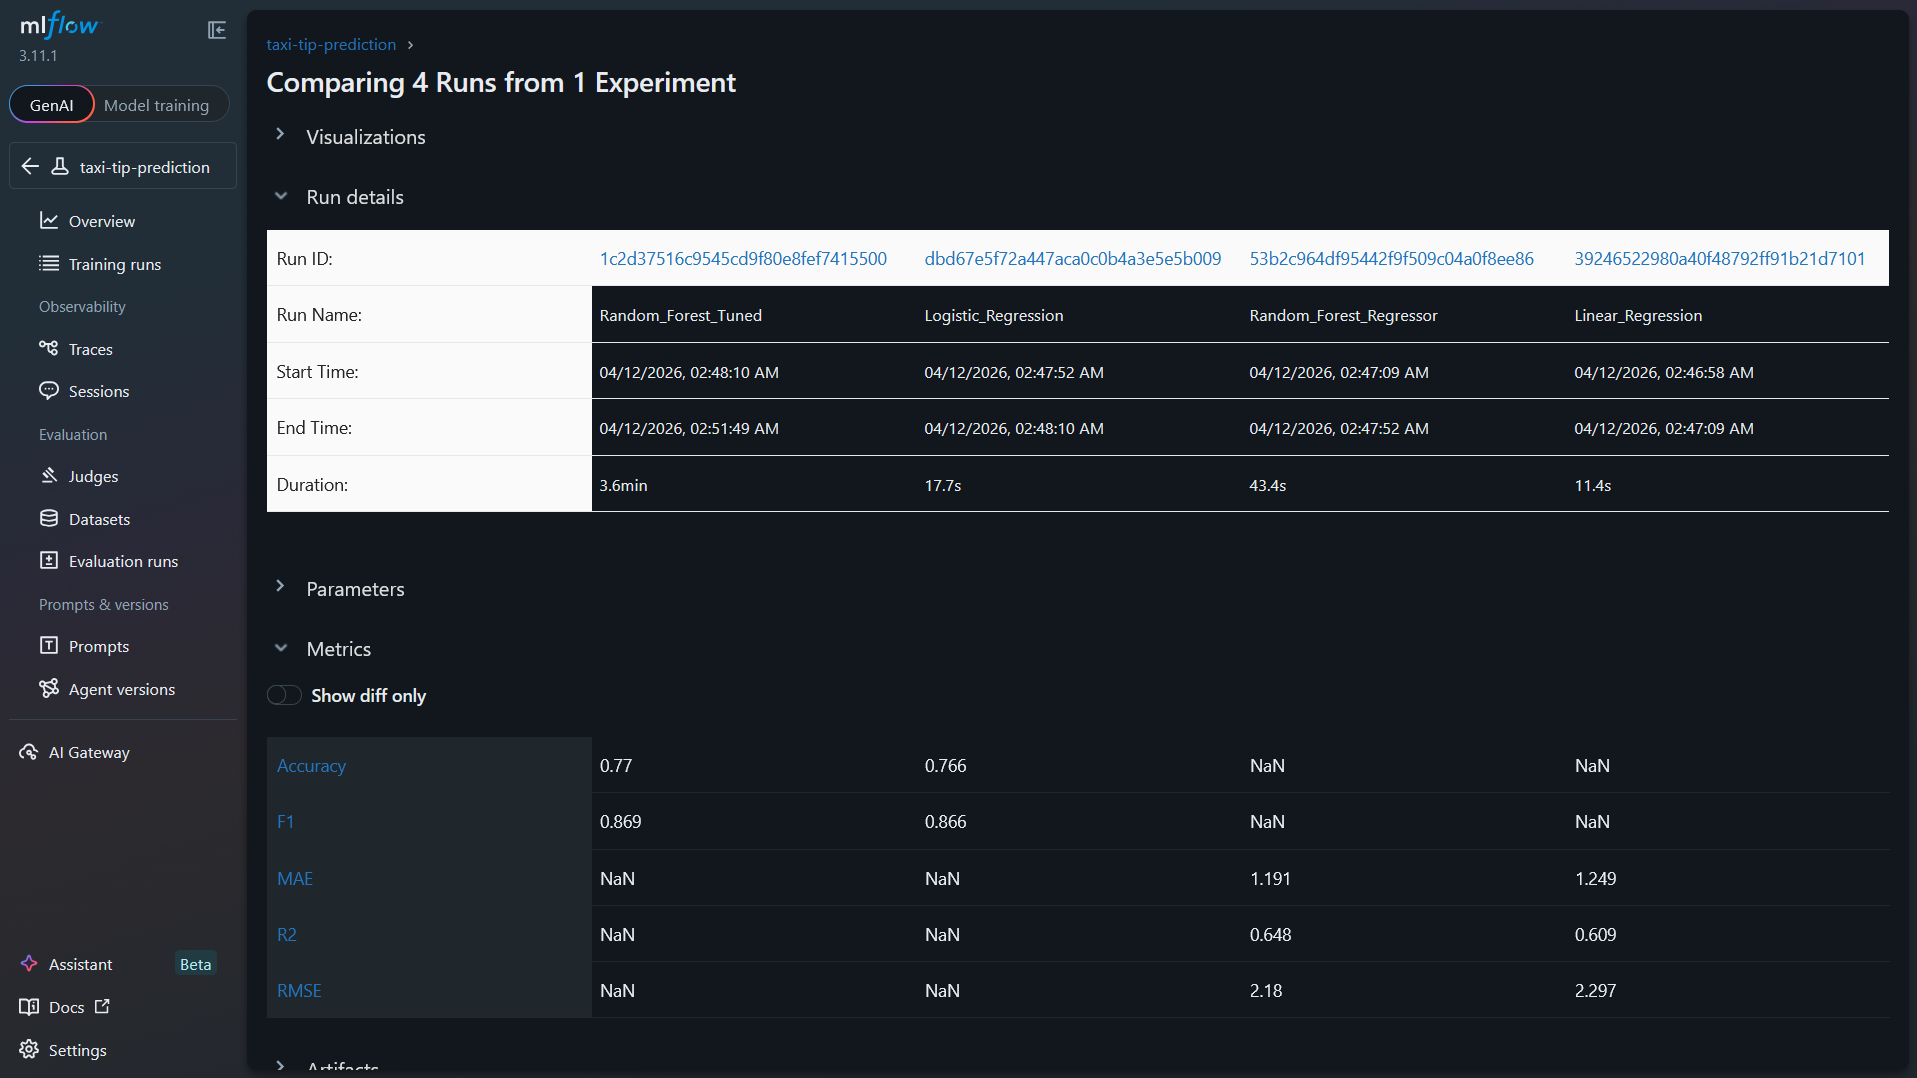

The Random Forest Regressor performed best for predicting exact tip amounts by achieving the highest R2 score of 0.648 alongside the lowest Mean Absolute Error of 1.191. For the classification task of predicting high tips the Random Forest Tuned model was the clear winner. It outperformed the baseline logistic model by securing a higher Accuracy of 0.77 with a top F1 score of 0.869.

Model Selection: The Random Forest Regressor was chosen to be registered as predicting the exact dollar amount of a tip provides much more actionable business value than a simple binary classification. 

#### Registering the Random Forest Regressor Model with Description using run ID 

In [15]:
import mlflow
from mlflow.tracking import MlflowClient

#Retrieves the experiment by name to get its ID
experiment_name = "taxi-tip-prediction"
experiment = mlflow.get_experiment_by_name(experiment_name)

#Searches for the most recently logged run in experiment
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    #Sorts by newest first random forest regressor to ensure we get the latest run
    filter_string="tags.model_type = 'Random Forest Regressor'",
    order_by=["metrics.R2 DESC"],
    #Limits to 1 result to get the most recent run and avoid confusion with multiple runs
    max_results=1
)

#Extract the run_id of the RFR dynamically from the dataframe
run_id = runs_df.iloc[0]["run_id"]
print(f"Dynamically found Run ID: {run_id}")

# Defines the model name and URI for registration
model_name = "taxi-tip-regressor"
model_uri = f"runs:/{run_id}/model"

# Registers the model to the MLflow Registry
registered_model = mlflow.register_model(model_uri=model_uri, name=model_name)

# Adds the version description documenting its performance
client = MlflowClient()
client.update_model_version(
    name=model_name,
    version=registered_model.version,
    description="Random Forest Regressor achieving an R2 of 0.648 and MAE of 1.191."
)

print(f"Model successfully registered as '{model_name}' version {registered_model.version}")

Dynamically found Run ID: b6fb168a12fe4dd1bdd527bb5e8392e1


Successfully registered model 'taxi-tip-regressor'.
2026/04/13 23:39:13 WARNING mlflow.tracking._model_registry.fluent: Run with id b6fb168a12fe4dd1bdd527bb5e8392e1 has no artifacts at artifact path 'model', registering model based on models:/m-11de99d553c84dfd934508fd2d37d869 instead
2026/04/13 23:39:14 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: taxi-tip-regressor, version 1
Created version '1' of model 'taxi-tip-regressor'.


Model successfully registered as 'taxi-tip-regressor' version 1


MLflow artifact creation was inconsistent and did not generate mlflow model for app.py/ docker hence manually saving model to project root:

In [ ]:
import joblib
from pathlib import Path

# Save the taxi-trip-regressor model directly to project root for easy access by the API
joblib.dump(rfreg_pipe, "taxi_tip_regressor.pkl")
print("Model saved as a physical file in your project folder!")

Model saved as a physical file in your project folder!


#### Load Model from Registry with Sample Prediction

In [16]:
import pandas as pd

# Grab a single row from the test set for the sample
sample_data = X_test.head(1)

# Points to the exact model and version in the registry
model_uri_registry = f"models:/{model_name}/{registered_model.version}"

# Loads the model and makes the sample prediction
loaded_model = mlflow.pyfunc.load_model(model_uri_registry)
prediction = loaded_model.predict(sample_data)

print("Model successfully loaded from registry.")
print(f"Predicted tip amount for sample trip: ${prediction[0]:.2f}")

Model successfully loaded from registry.
Predicted tip amount for sample trip: $2.79


The model was successfully loaded from the registry and predicted a tip amount of $2.70 as seen by the output from the code block above.

# Part 2: Model Serving with FastAPI
## Task 2.1: API Design & Implementation & 2.2: Enhanced API Features

Please check `app.py` for these two tasks.

## Task 2.3: API Testing

Coded `test_app.py` with 5 test cases refer to python file for code.

Image of output in terminal showing all 5 test cases passing 

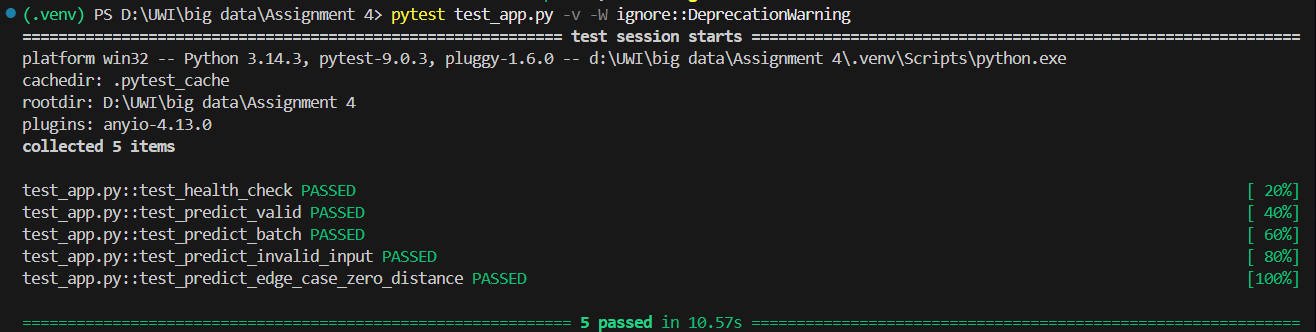

Screenshot of the auto-generated Swagger UI documentation at 127.0.0.1:8000/docs

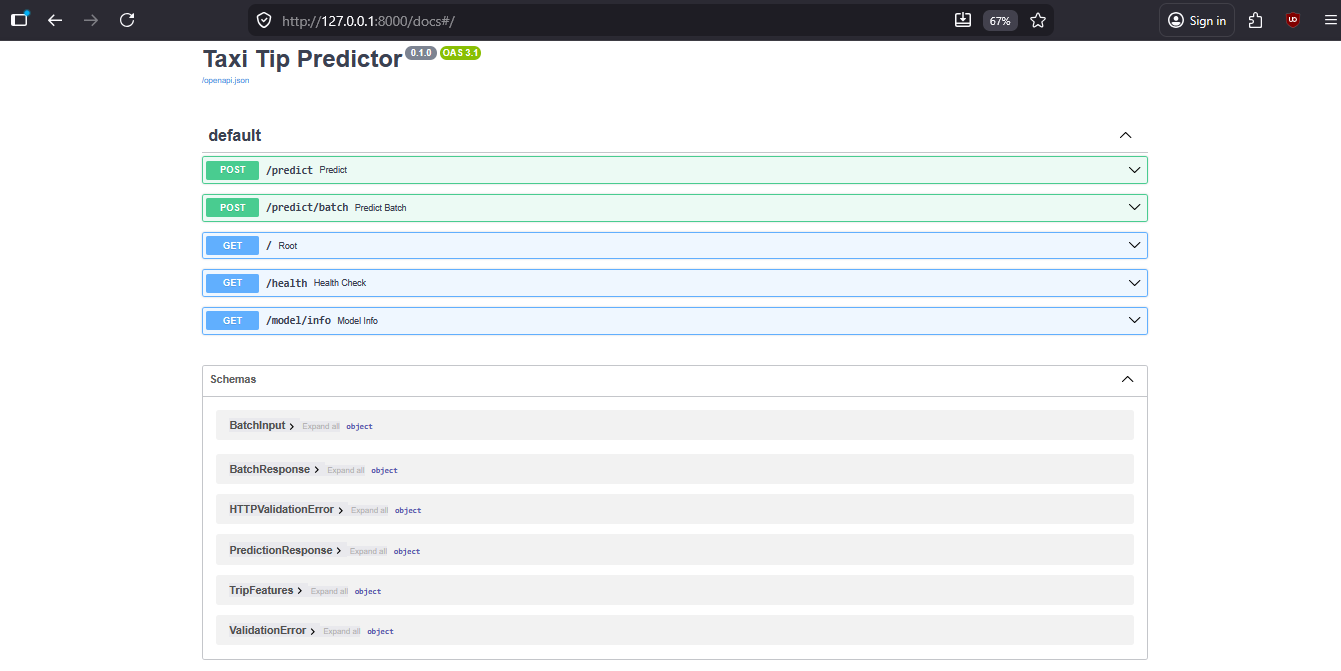

Screenshot of /predict endpoint expanded.

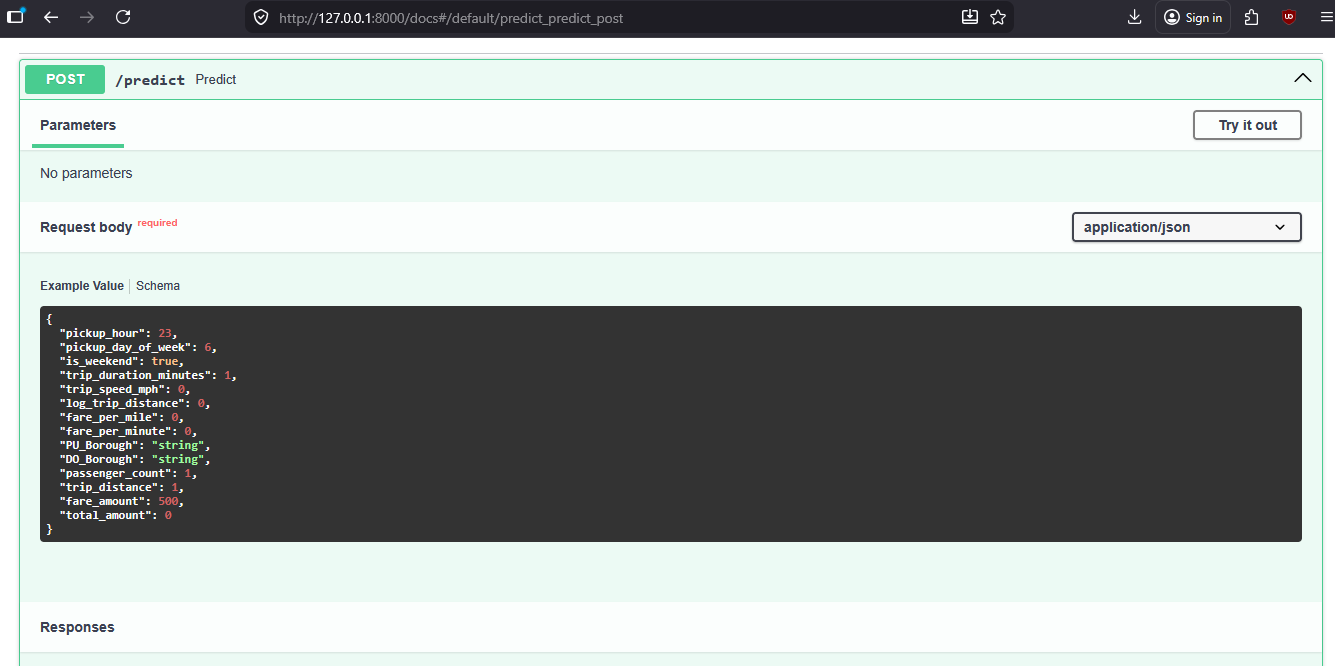  
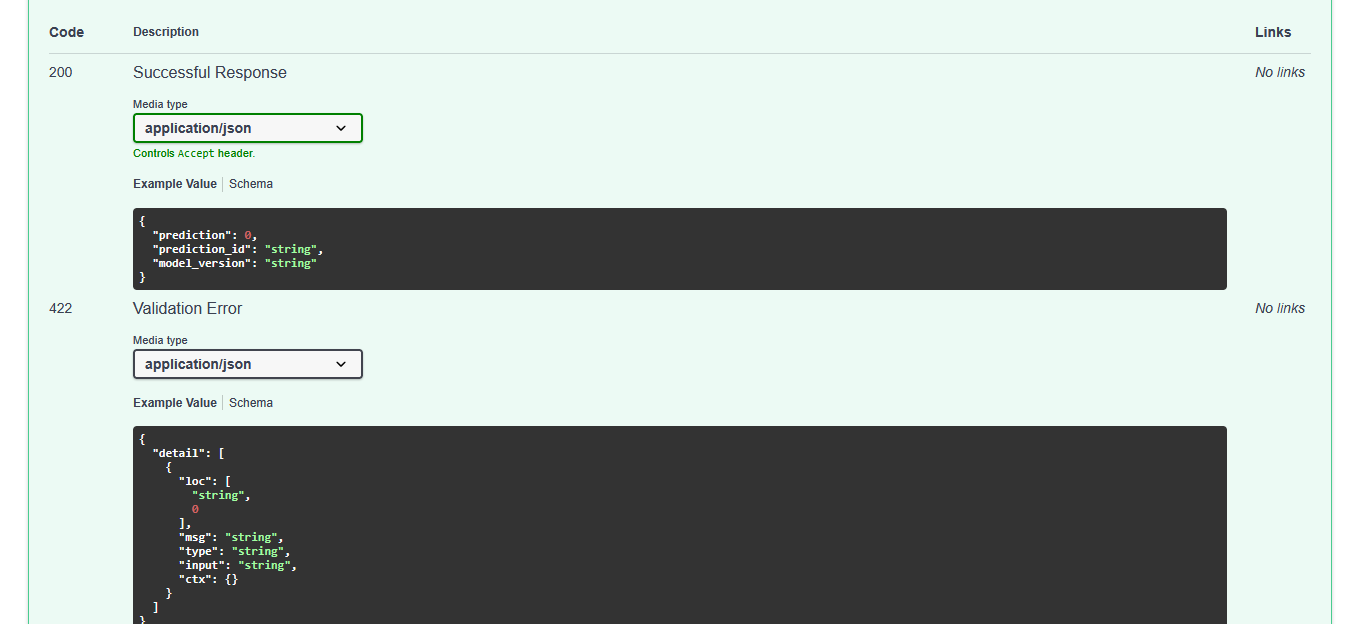


# Part 3: Containerization with Docker
## Task 3.1: Dockerfile & Image Building

#### Terminal showing successful image building "docker compose build api":

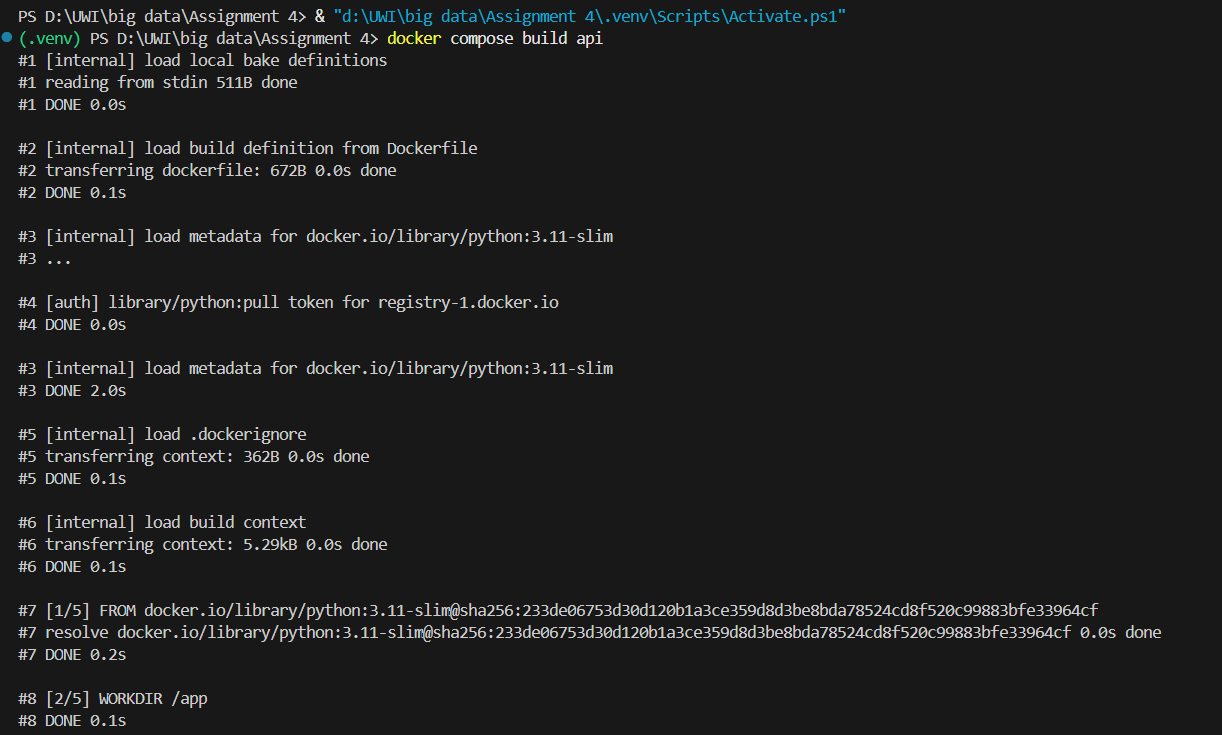

Continuation of previous command showing successful building of api, some of the output was omitted due to length.

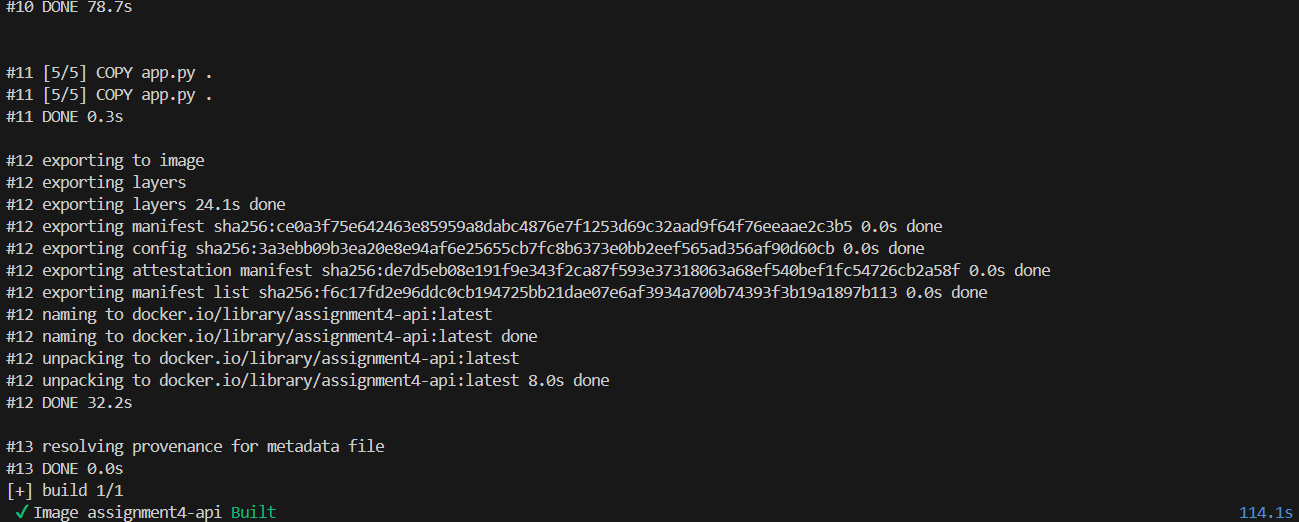

#### Image showing image creation and size:

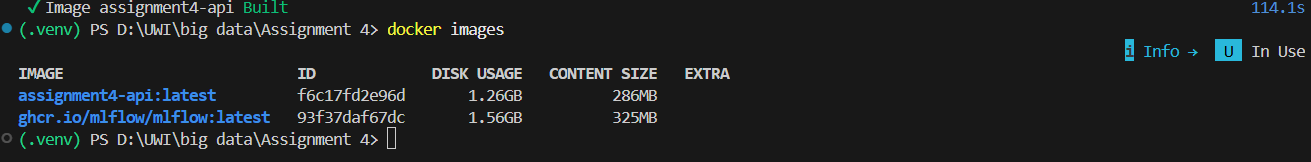

The Docker image for the FastAPI application was built successfully using the Docker Desktop engine and the reported image size is 1.26 GB.   



*Note: As seen in the terminal output above, the image assignment4-api: latest has a disk footprint of 1.26 GB. The content size is optimized at 286 MB due to the use of the python:3.11-slim base image, which excludes non-essential libraries.*

#### API Deployment and Service Verification:

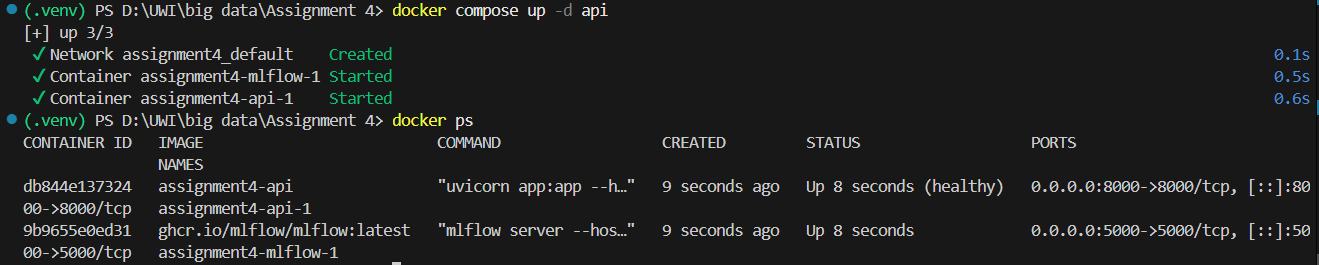

The deployment was initiated using `Docker Compose` to orchestrate both the FastAPI application and the MLflow tracking server within a unified network. As evidenced by the `docker ps` output, the `assignment4-api-1` container successfully transitioned to a **healthy** status, confirming that the model was correctly loaded into memory via the application's lifespan handler and the internal health check endpoint (`/health`) is responding. Both services are correctly mapped to their designated ports (**8000** for the API and **5000** for MLflow), ensuring the system is fully operational and accessible for external requests.

#### Test Accessibility and Prediction Verification:

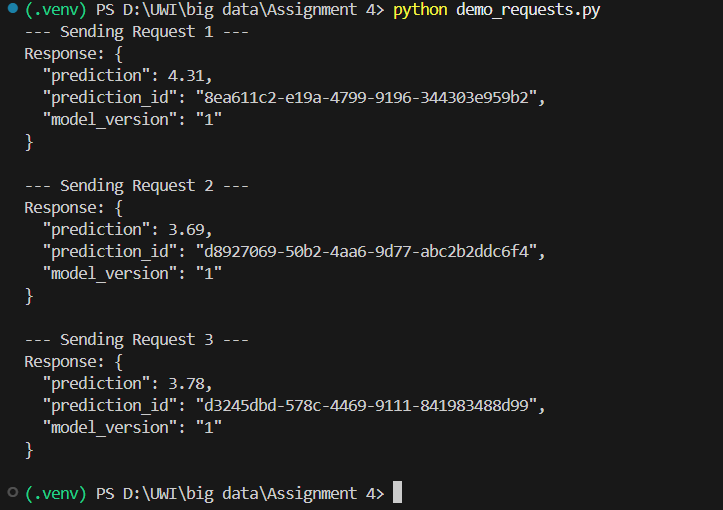

The containerized FastAPI service was verified by executing a test script from the host environment to ensure external accessibility. As shown in the terminal output above, three separate prediction requests were successfully processed, returning unique prediction IDs and consistent model output in the required JSON format. This confirms that the container's port mapping (8000:8000) is correctly configured and the internal Random Forest model is properly handling inference requests from outside the Docker network.

## Task 3.2: Docker Compose & Deployment Demo

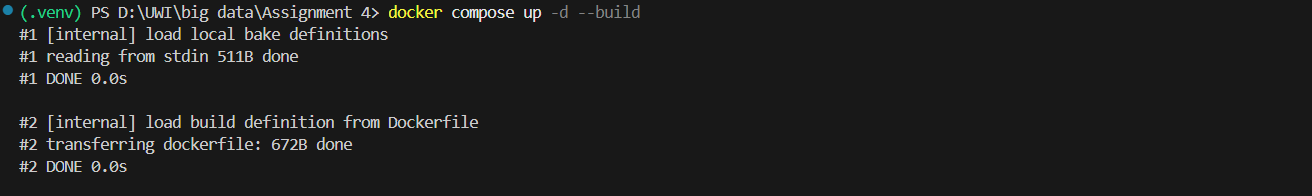  
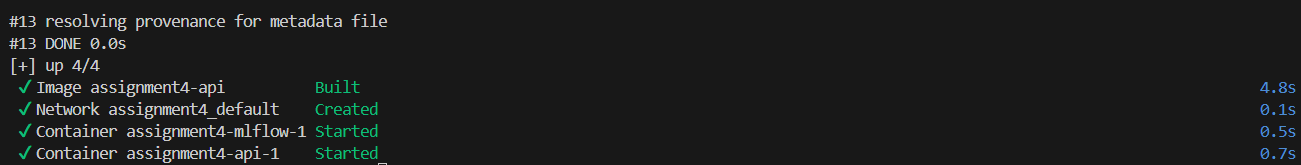